In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
DATA_PATH = 'data/PART2-26-01-26_reorg/PART2-26-01-26_reorg'
train_array = pd.read_csv(DATA_PATH + "/train_array.tsv", sep='\t')
train_flow = pd.read_csv(DATA_PATH + "/train_flow.tsv", sep='\t', low_memory=False)
train_participants = pd.read_csv(DATA_PATH + "/train_participants.tsv", sep='\t')

In [3]:
# Find missing values
tables = {
    "train_array": train_array,
    "train_flow": train_flow,
    "train_participants": train_participants,
}

for name, df in tables.items():
    print(f"========================================")
    print(f"TABLE: {name}")
    print(f"{df.shape[0]} rows, {df.shape[1]} columns")
    print(f"========================================")

    missing_counts = df.isnull().sum()
    missing_only = missing_counts[missing_counts > 0].sort_values(ascending=False)

    if len(missing_only) > 0:
        print("Columns with missing values: ")
        for col, count in missing_only.items():
            percent = (count / len(df)) * 100
            print(f"  - {col}: {count} missing ({percent:.2f}%)")
    else:
        print("  (No missing values found)")

    print(f"========================================")
    print("\n")

TABLE: train_array
16112494 rows, 7 columns
Columns with missing values: 
  - value: 427 missing (0.00%)


TABLE: train_flow
213624 rows, 9 columns
Columns with missing values: 
  - parent_population: 107286 missing (50.22%)
  - name: 83841 missing (39.25%)
  - value: 44 missing (0.02%)


TABLE: train_participants
3960 rows, 17 columns
Columns with missing values: 
  - main_publication_author: 1883 missing (47.55%)
  - geolocation: 799 missing (20.18%)
  - pubmed_ids: 121 missing (3.06%)
  - main_pmid: 121 missing (3.06%)




In [4]:
# ============================================================
# SECTION 1: Data Types & Basic Info
# ============================================================
# This tells us what kind of data each column holds:
# numeric (int/float), categorical (object), boolean, etc.

for name, df in tables.items():
    print(f"\n{'='*50}")
    print(f"TABLE: {name} — Column Types")
    print(f"{'='*50}")
    type_counts = df.dtypes.value_counts()
    print(type_counts.to_string())
    print("\nSample of column names + types:")
    print(df.dtypes.head(20).to_string())


TABLE: train_array — Column Types
object     5
int64      1
float64    1

Sample of column names + types:
marray_id          object
participant_id     object
timepoint           int64
gene_symbol        object
value             float64
platform_id        object
material           object

TABLE: train_flow — Column Types
object     6
float64    2
int64      1

Sample of column names + types:
flow_id                   int64
participant_id           object
timepoint               float64
parent_population        object
population_defnition     object
name                     object
unit                     object
value                   float64
material                 object

TABLE: train_participants — Column Types
object    15
int64      2

Sample of column names + types:
participant_id             object
subject                    object
biological_sex             object
race                       object
min_age                     int64
max_age                     int64
geolocation 

In [5]:
# ============================================================
# SECTION 2: Preview Each Table
# ============================================================
# .head() shows us a few rows so we can visually understand
# the structure before doing any analysis

for name, df in tables.items():
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    print(f"{'='*50}")
    display(df.head(5))


TABLE: train_array


,marray_id,participant_id,timepoint,gene_symbol,value,platform_id,material
0,BS_MARRAY___SDY61.SUB112830__ARM457.Day0__A1BG,SDY61.SUB112830,0,A1BG,7.180758,GPL570,peripheral blood mononuclear cell
1,BS_MARRAY___SDY61.SUB112830__ARM457.Day3__A1BG,SDY61.SUB112830,3,A1BG,6.690095,GPL570,peripheral blood mononuclear cell
2,BS_MARRAY___SDY61.SUB112830__ARM457.Day7__A1BG,SDY61.SUB112830,7,A1BG,6.810465,GPL570,peripheral blood mononuclear cell
3,BS_MARRAY___SDY61.SUB112832__ARM457.Day0__A1BG,SDY61.SUB112832,0,A1BG,7.091945,GPL570,peripheral blood mononuclear cell
4,BS_MARRAY___SDY61.SUB112832__ARM457.Day3__A1BG,SDY61.SUB112832,3,A1BG,6.472118,GPL570,peripheral blood mononuclear cell



TABLE: train_flow


,flow_id,participant_id,timepoint,parent_population,population_defnition,name,unit,value,material
0,427173,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+,Freq. of,WBC",live CD45+ cells?,cells/uL,176.220000,blood
1,427174,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ1: CD27,, IgD+,Freq. of,C...",Naive B cells,cells/uL,112.780800,blood
2,427175,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ2: CD27+,, IgD+,Freq. of,...",Memory class switched + non-class switched B c...,cells/uL,12.370644,blood
3,427176,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ3: CD27+,, IgD,Freq. of,C...",Memory class switched B cells,cells/uL,21.322620,blood
4,427177,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ4: CD27,, IgD,Freq. of,CD19+",B cells,cells/uL,29.781180,blood



TABLE: train_participants


,participant_id,subject,biological_sex,race,min_age,max_age,geolocation,investigation_id,investigation_name,arm_id,arm_name,data_source,description,basic_curation,pubmed_ids,main_pmid,main_publication_author
0,SDY269.SUB112836,SUB112836,female,White,28,28,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
1,SDY269.SUB112849,SUB112849,female,Black or African American,39,39,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
2,SDY269.SUB112854,SUB112854,male,Black or African American,46,46,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
3,SDY269.SUB112860,SUB112860,female,White,32,32,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
4,SDY269.SUB112881,SUB112881,female,Black or African American,29,29,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)


In [6]:
# ============================================================
# SECTION 3: Numeric Column Summary Statistics
# ============================================================
# For every numeric column, this gives us count, mean, std,
# min, 25th/50th/75th percentile, and max — a quick sanity
# check for outliers and scale differences

for name, df in tables.items():
    numeric_cols = df.select_dtypes(include='number')
    if not numeric_cols.empty:
        print(f"\n{'='*50}")
        print(f"TABLE: {name} — Numeric Summary")
        print(f"{'='*50}")
        display(numeric_cols.describe().T)


TABLE: train_array — Numeric Summary


,count,mean,std,min,25%,50%,75%,max
timepoint,16112494.0,6.516512,8.969962,-14.000000,0.000000,3.000000,7.00000,36.000000
value,16112067.0,6.054530,1.929751,-6.287712,4.266755,6.484391,6.82643,15.680015



TABLE: train_flow — Numeric Summary


,count,mean,std,min,25%,50%,75%,max
flow_id,213624.0,2.465297e+06,2.386345e+06,400728.0,611183.750000,664589.50,5.587649e+06,5641055.0
timepoint,213624.0,1.329871e+01,3.181101e+01,-7.0,0.000000,3.00,1.400000e+01,240.0
value,213580.0,3.603062e+02,4.982803e+03,-1.0,0.294398,3.28,2.699760e+01,193714.0



TABLE: train_participants — Numeric Summary


,count,mean,std,min,25%,50%,75%,max
min_age,3960.0,47.443182,21.420749,18.0,26.0,46.0,67.0,92.0
max_age,3960.0,47.725253,21.168404,18.0,27.0,46.0,67.0,92.0


In [7]:
# ============================================================
# SECTION 4: Categorical Column Summaries
# ============================================================
# For non-numeric columns, we want to know:
#   - How many unique values are there?
#   - What are the most common values (value_counts)?
# This is especially useful for train_participants (age, sex, study, etc.)

MAX_UNIQUE_TO_SHOW = 15  # only show value counts if cardinality is manageable

for name, df in tables.items():
    cat_cols = df.select_dtypes(include='object').columns
    if len(cat_cols) == 0:
        continue
    print(f"\n{'='*50}")
    print(f"TABLE: {name} — Categorical Columns")
    print(f"{'='*50}")
    for col in cat_cols:
        n_unique = df[col].nunique()
        print(f"\n  [{col}] — {n_unique} unique values")
        if n_unique <= MAX_UNIQUE_TO_SHOW:
            print(df[col].value_counts(dropna=False).to_string())
        else:
            print(f"  (too many to list — top 5 shown)")
            print(df[col].value_counts(dropna=False).head(5).to_string())


TABLE: train_array — Categorical Columns

  [marray_id] — 14992480 unique values
  (too many to list — top 5 shown)
marray_id
BS_MARRAY___SDY269.SUB112829__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112859__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112867__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112831__ARM1888.Day__UBE2B    3
BS_MARRAY___SDY269.SUB112836__ARM1888.Day__UBE2B    3

  [participant_id] — 208 unique values
  (too many to list — top 5 shown)
participant_id
SDY404.SUB120418    125336
SDY404.SUB120420    125336
SDY404.SUB120421    125336
SDY404.SUB120422    125336
SDY404.SUB120424    125336

  [gene_symbol] — 39665 unique values
  (too many to list — top 5 shown)
gene_symbol
GJA9      689
ACSBG2    689
SUB1      689
CLK1      689
NVL       689

  [platform_id] — 4 unique values
platform_id
GPL10558    8621304
GPL13158    6886012
GPL570       598644
GPL6947        6534

  [material] — 2 unique values
material
peripheral blood mononuclear cell    16105960
blood   

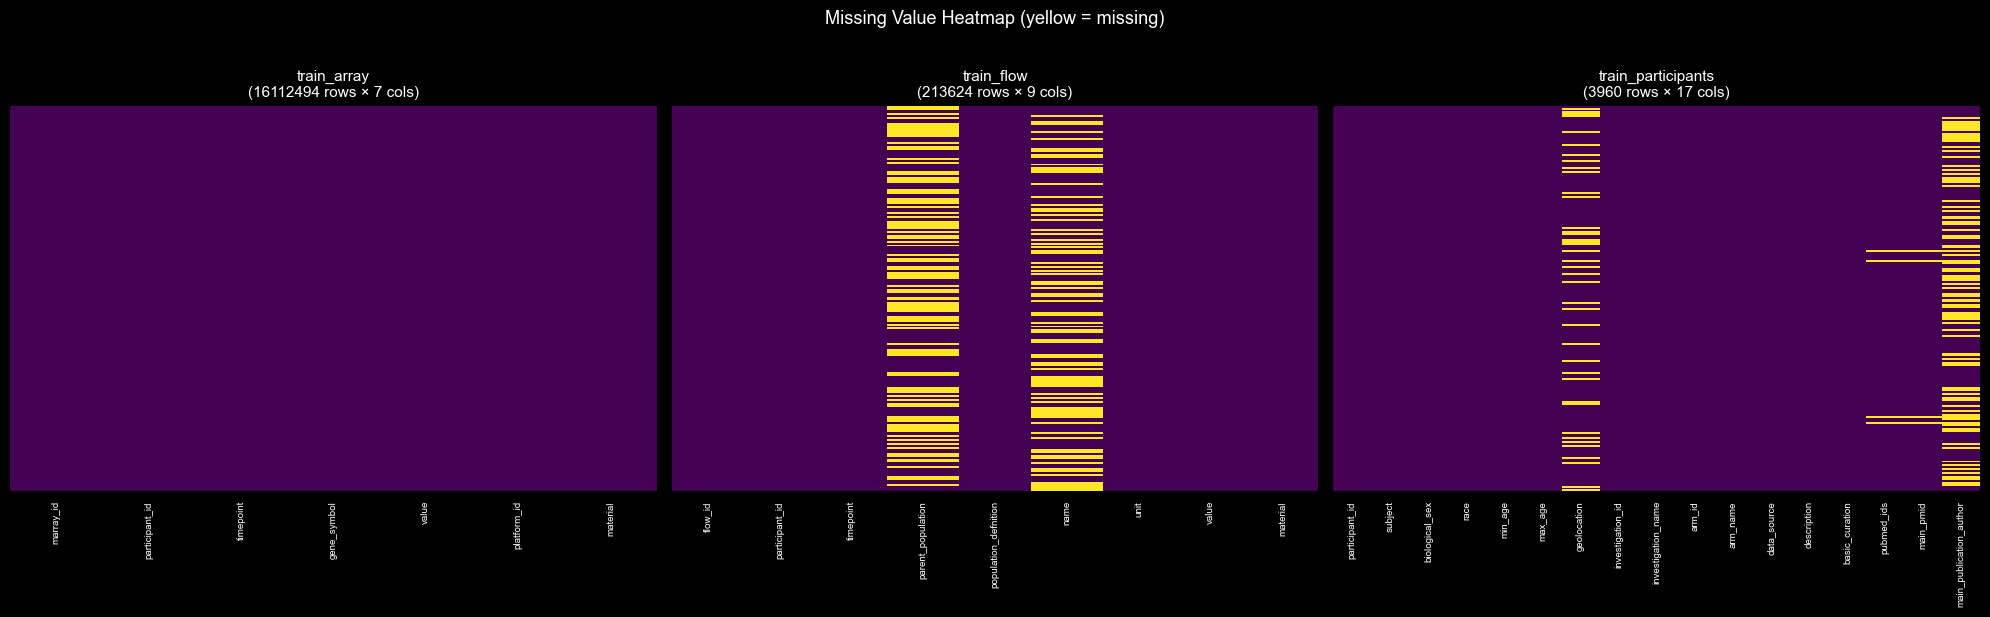

In [8]:
# ============================================================
# SECTION 5: Missing Value Heatmap
# ============================================================
# A visual representation of WHERE missing values occur.
# White = missing, colored = present. Helps spot patterns —
# e.g., are certain columns always missing together?

fig, axes = plt.subplots(1, len(tables), figsize=(20, 6))

for ax, (name, df) in zip(axes, tables.items()):
    # Sample rows if table is large, to keep the plot readable
    sample = df.sample(min(200, len(df)), random_state=42) if len(df) > 200 else df
    sns.heatmap(
        sample.isnull(),
        ax=ax,
        cbar=False,
        yticklabels=False,
        cmap='viridis'
    )
    ax.set_title(f"{name}\n({df.shape[0]} rows × {df.shape[1]} cols)", fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)

plt.suptitle("Missing Value Heatmap (yellow = missing)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

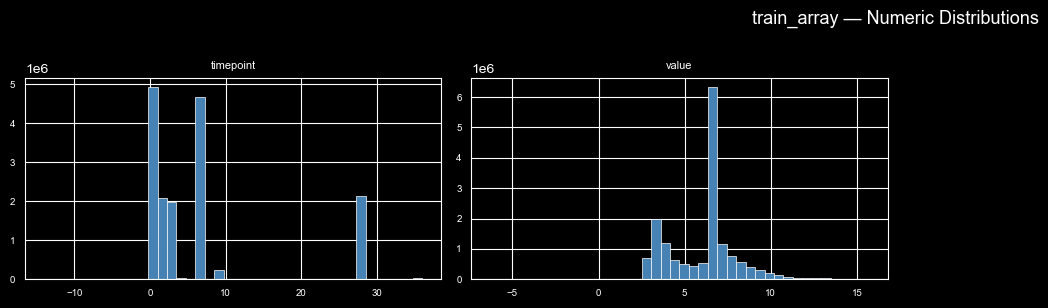

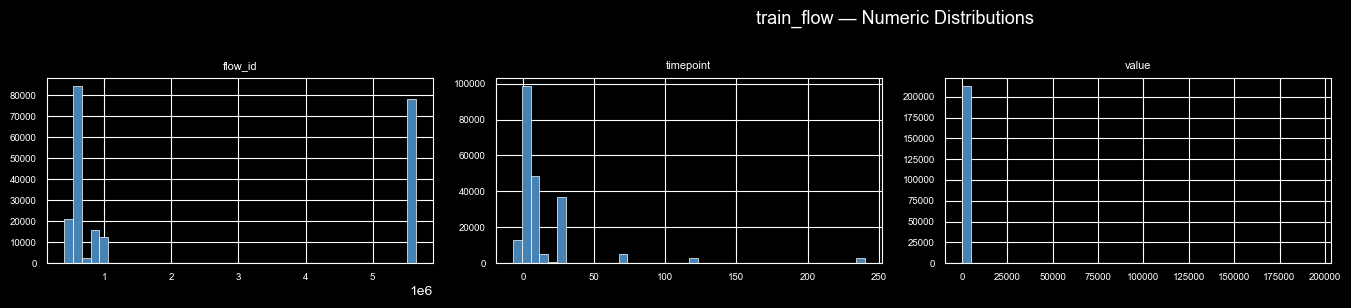

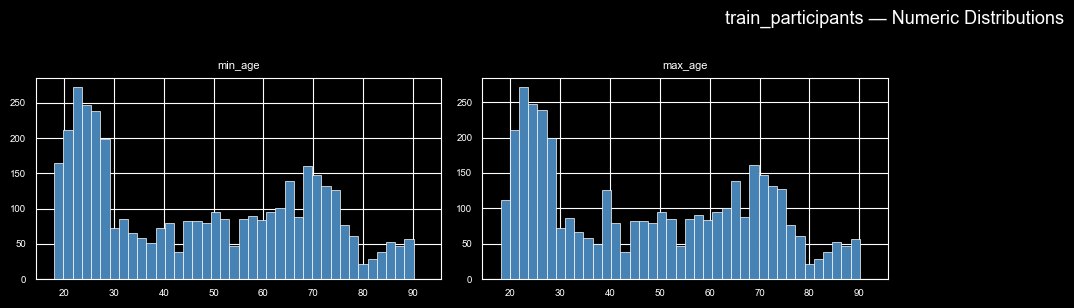

In [9]:
# ============================================================
# SECTION 6: Distributions of Numeric Columns
# ============================================================
# Histograms for every numeric column. This is key for spotting:
#   - Skewed distributions (common in biological assay data)
#   - Bimodal distributions (could indicate subgroups)
#   - Values that seem unrealistically extreme (data quality issues)

for name, df in tables.items():
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    if not numeric_cols:
        continue

    n_cols = 4
    n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division trick

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
        axes[i].set_title(col, fontsize=8)
        axes[i].set_xlabel('')
        axes[i].tick_params(labelsize=7)

    # Hide any unused subplot panels
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{name} — Numeric Distributions", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

Likely demographic columns found: ['biological_sex', 'race', 'min_age', 'max_age', 'arm_id', 'arm_name']


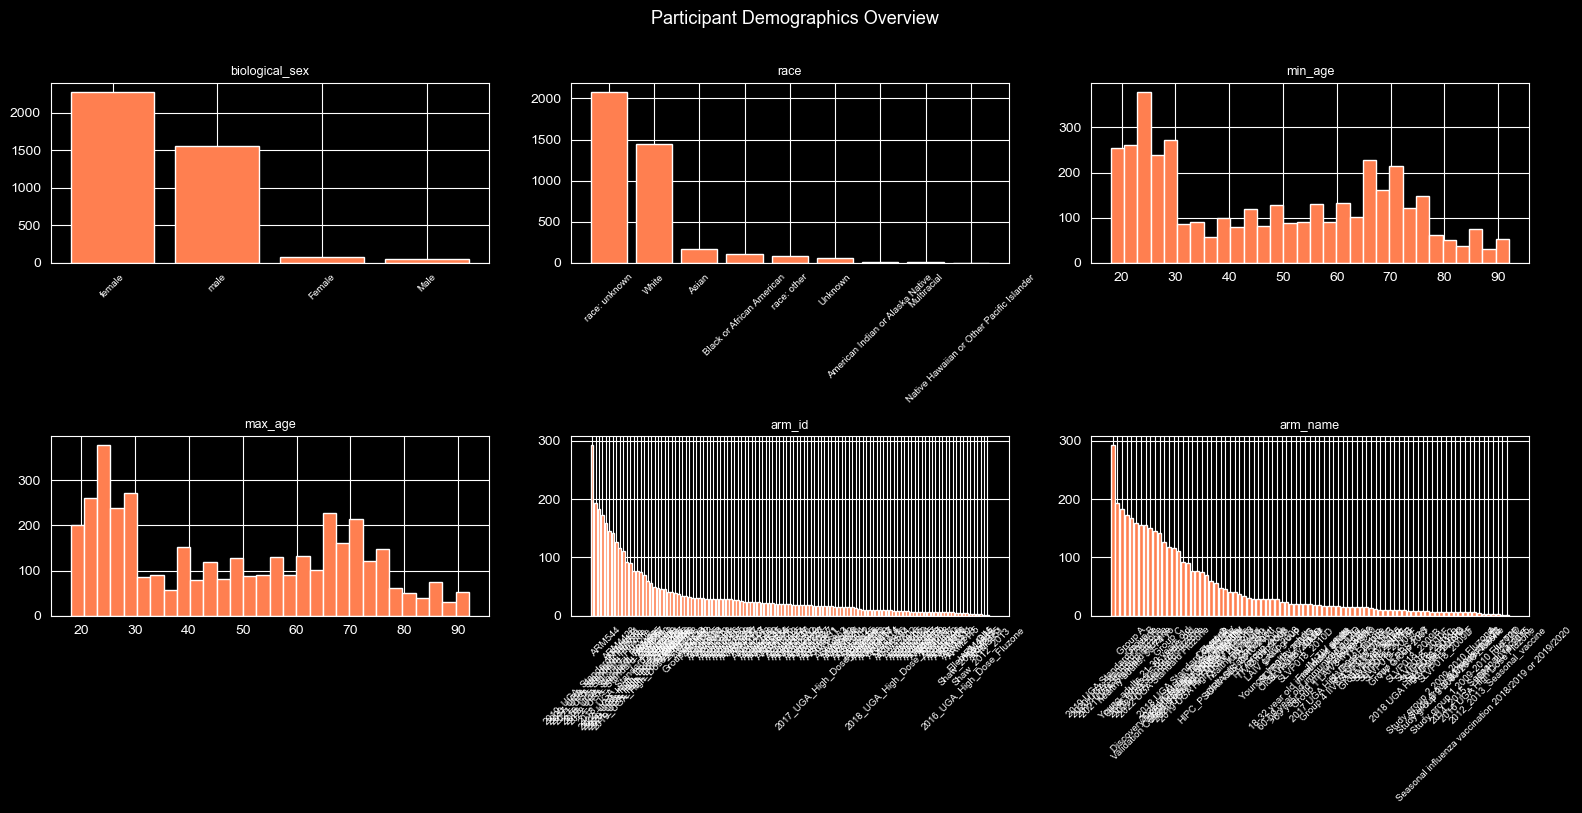

In [10]:
# ============================================================
# SECTION 7: Participant-Level Summary (train_participants focus)
# ============================================================
# Since participants is the "master table", let's get a clearer
# picture of the cohort — age, sex, study, timepoints, etc.

df_p = train_participants.copy()

# Identify likely demographic columns by common naming patterns
demo_candidates = [c for c in df_p.columns if any(
    kw in c.lower() for kw in ['age', 'sex', 'gender', 'study', 'arm', 'cohort', 'site', 'year', 'race', 'ethnicity']
)]

print("Likely demographic columns found:", demo_candidates)

if demo_candidates:
    n_cols = min(3, len(demo_candidates))
    n_rows = -(-len(demo_candidates) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(demo_candidates):
        if df_p[col].dtype == 'object' or df_p[col].nunique() < 20:
            # Categorical or low-cardinality: bar chart
            vc = df_p[col].value_counts(dropna=False)
            axes[i].bar(vc.index.astype(str), vc.values, color='coral', edgecolor='white')
            axes[i].set_title(col, fontsize=9)
            axes[i].tick_params(axis='x', rotation=45, labelsize=7)
        else:
            # Continuous: histogram
            axes[i].hist(df_p[col].dropna(), bins=30, color='coral', edgecolor='white')
            axes[i].set_title(col, fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Participant Demographics Overview", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

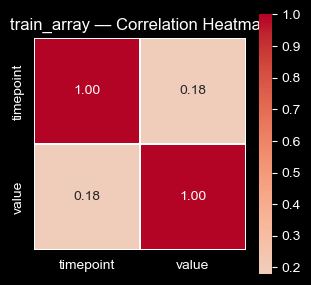

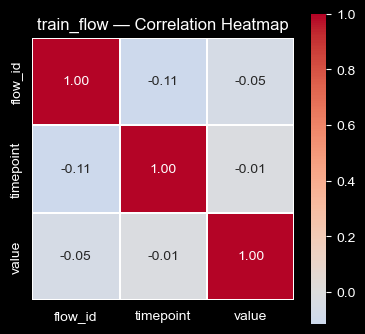

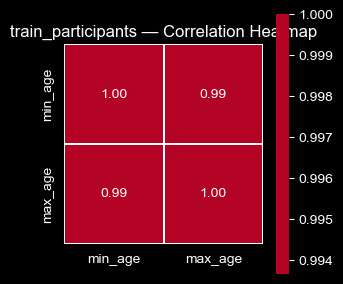

In [11]:
# ============================================================
# SECTION 8: Correlation Heatmap for Numeric Columns
# ============================================================
# Shows pairwise correlations between numeric columns.
# Useful for spotting redundant features (r ≈ 1) or
# potentially interesting relationships (r ≈ 0.5–0.8).
# We skip tables with too many columns to avoid an unreadable plot.

MAX_COLS_FOR_CORR = 40

for name, df in tables.items():
    numeric_df = df.select_dtypes(include='number')
    if numeric_df.shape[1] < 2:
        print(f"{name}: Not enough numeric columns for correlation.")
        continue
    if numeric_df.shape[1] > MAX_COLS_FOR_CORR:
        print(f"{name}: {numeric_df.shape[1]} numeric cols — too many for a readable heatmap, skipping.")
        continue

    corr = numeric_df.corr()
    fig, ax = plt.subplots(figsize=(min(16, corr.shape[0] * 0.6 + 2),
                                    min(14, corr.shape[0] * 0.5 + 2)))
    sns.heatmap(
        corr, ax=ax, cmap='coolwarm', center=0,
        annot=corr.shape[0] <= 20,  # only annotate if small enough
        fmt='.2f', linewidths=0.3, square=True
    )
    ax.set_title(f"{name} — Correlation Heatmap", fontsize=12)
    plt.tight_layout()
    plt.show()